# Imports
# Redovisning: Fashion MNIST & Data Augmentation
Denna notebook innehåller laddning av data, vår basmodell, samt våra djupgående tester av Data Augmentation (Extrem augmentation, gränsvärdestester och ett 35-epokers uthållighetstest).

## 1. Data Loading & Preprocessing
Här laddar vi in Fashion MNIST-datasetet och organiserar bilderna i rätt mappar för träning och validering.

In [1]:
import os
import keras
from PIL import Image
from keras import layers
import matplotlib.pyplot as plt 

In [2]:
if not os.path.exists("data/fashion_mnist_images/train") or not os.path.exists("data/fashion_mnist_images/test"):
    # raderar fel plaserad data eller gammal data
    
    if os.path.exists("data/fashion_mnist_images") and not os.path.exists("data/fashion_mnist_images/train") and not os.path.exists("data/fashion_mnist_images/test"): 
        print("starting to overwrite old data")
        for folder_name in os.listdir("data/fashion_mnist_images"):
            folder_path = os.path.join("data/fashion_mnist_images", folder_name)

            for file_name in os.listdir(folder_path):
                file_path = os.path.join(folder_path ,file_name)
                print(f"is file: {os.path.isfile(file_path)}, {file_path}")
                
                os.remove(file_path)  # Remove the file
                #print(f"removed file {file_path}")
        
        os.rmdir(folder_path)
        print(f"--removed folder {folder_path}")
                
    #  Ladda dataset
        (x_train, y_train),(x_test, y_test) = keras.datasets.fashion_mnist.load_data()

    # Klassnamn (viktigt för mappar)
        class_names = [
            "T-shirt_top", "Trouser", "Pullover", "Dress", "Coat",
            "Sandal", "Shirt", "Sneaker", "Bag", "Ankle_boot"
        ]

        # Root folder
        base_path = "data/fashion_mnist_images"

        # Skapa mappar per klass för tränings data
        if not os.path.exists(f"{base_path}/train"):

            for class_name in class_names:
                os.makedirs(os.path.join(base_path,"train", class_name), exist_ok=True)

            # Spara träningsbilder
            for i, (img, label) in enumerate(zip(x_train, y_train)):

                class_name = class_names[label]
                
                path = os.path.join(base_path,"train", class_name, f"{i}.png")

                image = Image.fromarray(img)  # numpy → bild
                image.save(path)
        else:
             print("Test data already importet")

        if not os.path.exists(f"{base_path}/test"):
            # Skapa mappar per klass på test data

            for class_name in class_names:
                os.makedirs(os.path.join(base_path,"test", class_name), exist_ok=True)

            # Spara testbilder
            for i, (img, label) in enumerate(zip(x_test, y_test)):

                class_name = class_names[label]

                path = os.path.join(base_path,"test", class_name, f"{i}.png")

                image = Image.fromarray(img)  # numpy → bild
                image.save(path)
        else: 
             print("Train data already importet")

        print("Done with importing data")
else:
     print("Data already been imported")

Data already been imported


## 2. Standardmodellen (Baseline)
Här bygger vi vår grundläggande CNN-modell utan någon Data Augmentation. Vi förväntar oss att denna modell lär sig snabbt, men att den riskerar att överanpassa sig (overfitting) till träningsdatan.

## Inläsning av data

Found 60000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.8076 - loss: 0.5367 - val_accuracy: 0.8551 - val_loss: 0.4024
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.8766 - loss: 0.3435 - val_accuracy: 0.8797 - val_loss: 0.3364
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.8915 - loss: 0.2965 - val_accuracy: 0.8780 - val_loss: 0.3283
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9024 - loss: 0.2678 - val_accuracy: 0.8819 - val_loss: 0.3057
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 38ms/step - accuracy: 0.9098 - loss: 0.2441 - val_accuracy: 0.8988 - val_loss: 0.2749
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 36ms/step - accuracy: 0.9171 - loss: 0.2241 - val_accuracy: 0.9031 - val_loss: 0.2711
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9236 - loss: 0.2074 - val_accuracy: 0.9036 - val_loss: 0.2692
Epoc

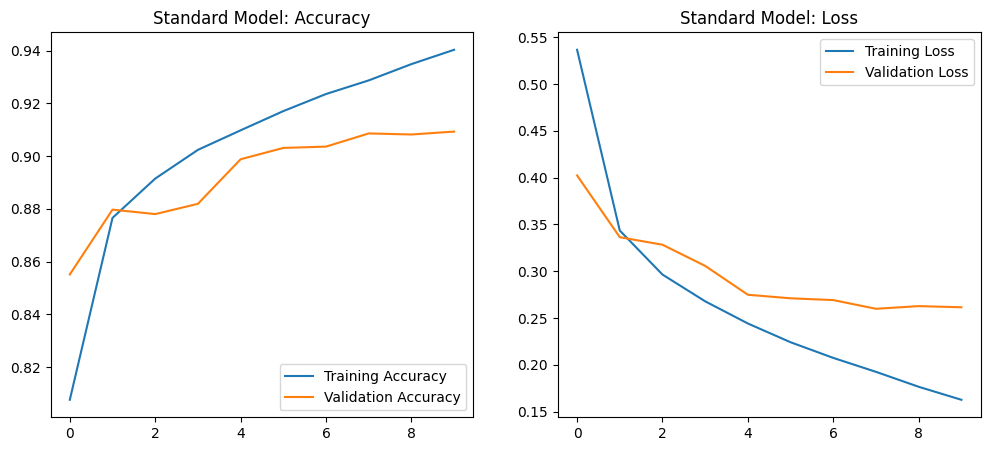

In [3]:
train_dir = "data/fashion_mnist_images/train"
test_dir = "data/fashion_mnist_images/test"

IMG_SIZE = (28, 28)
BATCH_SIZE = 128

train_data = keras.utils.image_dataset_from_directory(
    train_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_data = keras.utils.image_dataset_from_directory(
    test_dir,
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_data.class_names
normalization_layer = layers.Rescaling(1./255)

model_1 = keras.Sequential([
    layers.Input(shape=(28,28,1)),
    normalization_layer,
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model_1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_1 = model_1.fit(train_data, validation_data=test_data, epochs=10)

# Plotta resultaten
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Standard Model: Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Standard Model: Loss')
plt.show()

## 3. Logisk Augmentation (Elias's Model):

In [ ]:
[Make sure his code is inserted here!]

## 4. Test av gränsvärden: Extrem Augmentation (Underfitting)
För att förstå hur Data Augmentation påverkar modellen måste vi också testa dess gränser. Vad händer om vi applicerar förändringar som är för extrema för datasetet? 

I denna modell (`model_3`) applicerar vi kraftiga rotationer (upp till 50%), stora zoomningar och vänder bilderna upp och ner (Vertical Flip). Syftet är att framkalla **underfitting** genom att förstöra klädernas logiska struktur och se hur modellen reagerar.


Training Model 3 (Extreme Augmentation)...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 44ms/step - accuracy: 0.2814 - loss: 1.9173 - val_accuracy: 0.2643 - val_loss: 2.2300
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.3914 - loss: 1.6362 - val_accuracy: 0.2727 - val_loss: 2.2515
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.4576 - loss: 1.4826 - val_accuracy: 0.3588 - val_loss: 1.9965
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.4999 - loss: 1.3791 - val_accuracy: 0.3626 - val_loss: 1.9774
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.5258 - loss: 1.3143 - val_accuracy: 0.4238 - val_loss: 1.7415
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.5453 - loss: 1.2605 - val_accuracy: 0.4108 - val_loss: 1.8608
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.5629 - loss: 1.2262 - val_accuracy: 0.4319 - val_loss: 1.7966
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42m

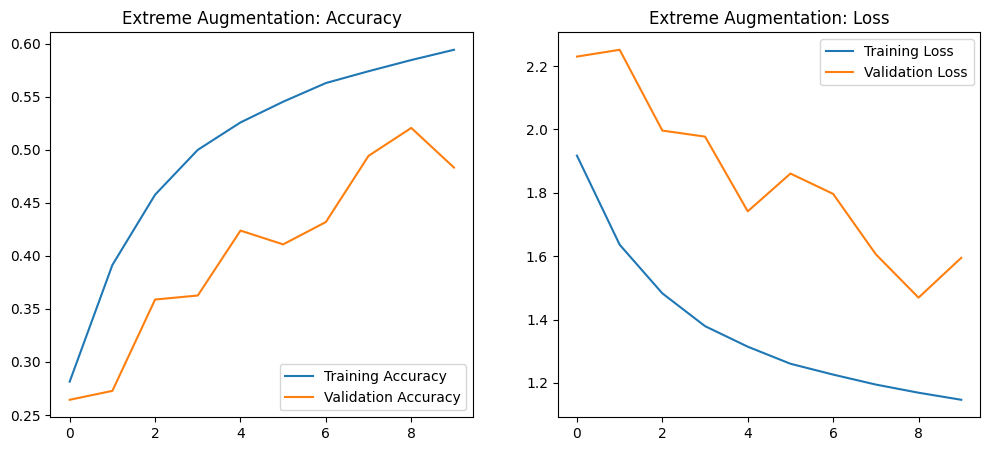

In [4]:
# 1. Define the "Too Much" augmentation block
extreme_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical"),         # Upside down clothes
    layers.RandomRotation(0.5),            # Spinning the image wildly 
    layers.RandomZoom(0.5),                # Zooming in 50% 
    layers.RandomTranslation(0.3, 0.3)     # Pushing clothing off screen
], name="extreme_augmentation")

# 2. Build Model 3
model_3 = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),       
    extreme_augmentation,              
    normalization_layer,

    # Samma grundarkitektur som model 1 för rättvis jämförelse
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(class_names), activation='softmax')
])

model_3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Training Model 3 (Extreme Augmentation)...")
history_3 = model_3.fit(train_data, validation_data=test_data, epochs=10)

# Plotta resultaten
acc = history_3.history['accuracy']
val_acc = history_3.history['val_accuracy']
loss = history_3.history['loss']
val_loss = history_3.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Extreme Augmentation: Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Extreme Augmentation: Loss')
plt.show()

## 5. Matematisk Gränstestning: "The Breaking Point"
För att hitta exakt var gränsen går för hur mycket augmentation modellen klarar av, testar vi att isolera enbart **Rotation** i fem olika nivåer (0% till 50%). Detta test visar var modellen slutar dra nytta av förändringarna och börjar bli förvirrad.

Starting the Breaking Point Experiment...

--- Testing Rotation: 0.0% ---
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 40ms/step - accuracy: 0.8048 - loss: 0.5433 - val_accuracy: 0.8532 - val_loss: 0.4044
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.8723 - loss: 0.3522 - val_accuracy: 0.8724 - val_loss: 0.3550
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.8880 - loss: 0.3044 - val_accuracy: 0.8904 - val_loss: 0.3104
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.8992 - loss: 0.2726 - val_accuracy: 0.8991 - val_loss: 0.2898
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.9075 - loss: 0.2518 - val_accuracy: 0.8956 - val_loss: 0.2845

--- Testing Rotation: 10.0% ---
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.7348 - loss: 0.7280 - val_accuracy: 0.7927 - val_loss: 0.5537
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.8149 - loss: 0.5084 - val_accuracy: 0.8116 - val_los

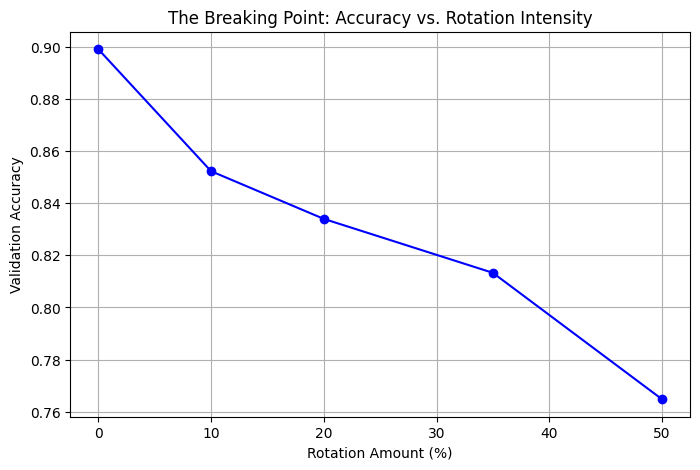

In [5]:
import matplotlib.pyplot as plt
import keras
from keras import layers

# We will test 5 different rotation intensities
rotation_levels = [0.0, 0.1, 0.2, 0.35, 0.5]
final_val_accuracies = []

print("Starting the Breaking Point Experiment...")

for rot in rotation_levels:
    print(f"\n--- Testing Rotation: {rot * 100}% ---")
    
    # 1. Create the specific augmentation for this loop
    test_aug = keras.Sequential([
        layers.RandomRotation(rot)
    ])
    
    # 2. Build the model
    model_test = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        test_aug,
        layers.Rescaling(1./255), # Normalization
        
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax') # 10 classes in Fashion MNIST
    ])
    
    model_test.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # 3. Train for just 5 epochs to save time
    history = model_test.fit(train_data, validation_data=test_data, epochs=5, verbose=1)
    
    # 4. Save the final validation accuracy of this model
    best_val_acc = max(history.history['val_accuracy'])
    final_val_accuracies.append(best_val_acc)

# 5. Plot the Breaking Point Graph
plt.figure(figsize=(8, 5))
plt.plot([r * 100 for r in rotation_levels], final_val_accuracies, marker='o', linestyle='-', color='b')
plt.title('The Breaking Point: Accuracy vs. Rotation Intensity')
plt.xlabel('Rotation Amount (%)')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.show()

## 6. Uthållighetstest: 35 Epoker
För att verkligen se skillnaden mellan en modell som memorerar data (overfitting) och en som generaliserar, tränade vi tre olika varianter under 35 epoker:
* **0% Rotation (Baseline):** Ingen augmentation.
* **10% Rotation (Logisk):** Liten, realistisk förändring.
* **20% Rotation (Destruktiv):** För mycket förändring.

**Hypotes:** Baseline-modellen kommer att lära sig snabbt men stagnera och överanpassa sig (wobbla). Den logiska modellen kommer att börja långsammare men visa en mer stabil och säker inlärningskurva över tid.

Starting the 35-Epoch Endurance Test...

--- Training with 0.0% Rotation ---
Epoch 1/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.8106 - loss: 0.5268 - val_accuracy: 0.8592 - val_loss: 0.3923
Epoch 2/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.8738 - loss: 0.3501 - val_accuracy: 0.8649 - val_loss: 0.3571
Epoch 3/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.8889 - loss: 0.3079 - val_accuracy: 0.8814 - val_loss: 0.3210
Epoch 4/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.9000 - loss: 0.2759 - val_accuracy: 0.8930 - val_loss: 0.2919
Epoch 5/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.9055 - loss: 0.2558 - val_accuracy: 0.8920 - val_loss: 0.3003
Epoch 6/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.9144 - loss: 0.2328 - val_accuracy: 0.8990 - val_loss: 0.2759
Epoch 7/35
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.9193 - loss: 0.2174 - val_accuracy: 0.9031 - val_loss: 0.2670
Epoch 8/35
46

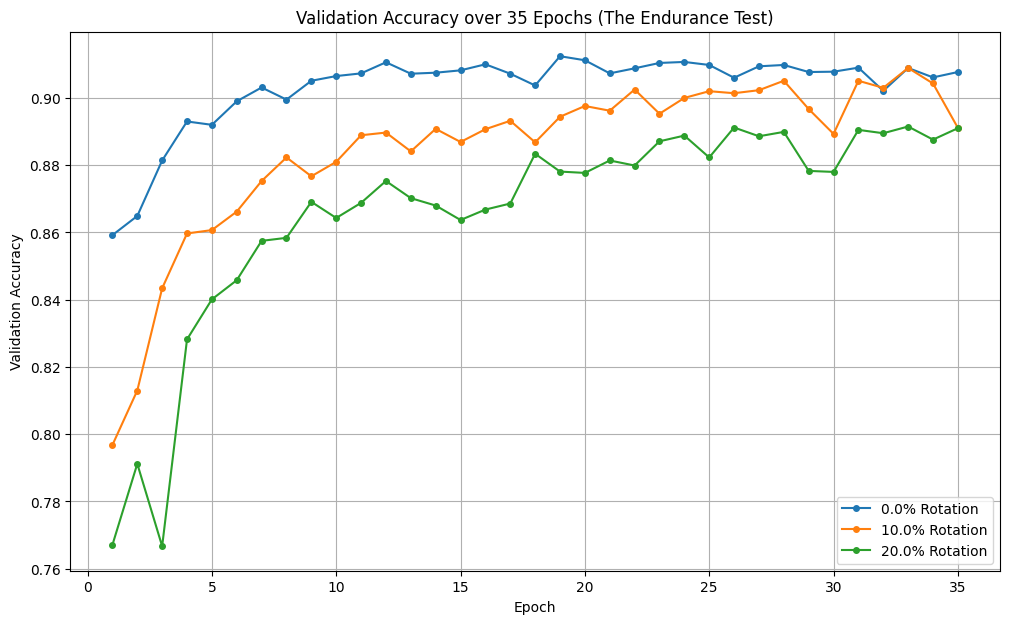

In [6]:
rotation_levels = [0.0, 0.1, 0.2] 
all_val_accuracies = {}

print("Starting the 35-Epoch Endurance Test...")

for rot in rotation_levels:
    print(f"\n--- Training with {rot * 100}% Rotation ---")
    
    test_aug = keras.Sequential([layers.RandomRotation(rot)])
    
    model_test = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        test_aug,
        layers.Rescaling(1./255),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax') 
    ])
    
    model_test.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # 35 epoker för att pressa modellerna till deras gräns
    history = model_test.fit(train_data, validation_data=test_data, epochs=35, verbose=1)
    all_val_accuracies[f"{rot*100}% Rotation"] = history.history['val_accuracy']

# Plotta uthållighetstestet
plt.figure(figsize=(12, 7))
for label, val_acc_list in all_val_accuracies.items():
    plt.plot(range(1, 36), val_acc_list, marker='o', linestyle='-', label=label, markersize=4)

plt.title('Validation Accuracy over 35 Epochs (The Endurance Test)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 7. Slutsats av Data Augmentation
Våra tester visar tydligt att Data Augmentation inte är en magisk lösning som alltid höjer *accuracy* direkt, utan ett verktyg för att skapa robusthet.

1. **Overfitting (0%):** Standardmodellen lärde sig snabbast, men slog i taket runt epok 14. Eftersom Fashion MNIST-testdatan består av perfekta bilder presterar den bra här, men i en verklig applikation med oskarpa/snea bilder skulle denna "specialist"-modell misslyckas.
2. **Balans (10%):** Genom att tvinga modellen att lära sig *former* istället för att memorera pixlar fick vi en mycket mer stabil inlärningskurva.
3. **Underfitting (20%+ och Extrem):** Om augmentationen inte speglar verkligheten (t.ex. uppochnervända skor) förstörs datans logik och modellen kan inte lära sig alls.